# Benchmark electrónico legacy con polos N49

Reproduce el caso electrónico puro de `TDNEGF_exciton_B` con el código nuevo `TDNEGF` usando polos N49.  
Sin LLG. Sin luz. Sin bias.

**Referencia**: `TDNEGF_exciton_B/parallel.jl` + `main_parallel.jl` (parámetros `old_kwargs`: nx=10, ny=2, n=40)

**Etapa**: Benchmark electrónico mínimo (Etapa 1 del reinicio)

In [70]:
using Pkg
Pkg.activate(joinpath(dirname(dirname(@__DIR__))))

using TDNEGF
using DifferentialEquations
using LinearAlgebra
using Statistics
using DelimitedFiles
using JLD2

  Activating project at `~/jalil_codes/Projects_2026/TDNEGF`


## Sección 1: Parámetros congelados

Todos los parámetros físicos se definen aquí y no se modifican en el resto del notebook.

### Mapa de parámetros: legacy → nuevo

| Parámetro legacy | Nombre nuevo | Significado físico | Unidades | Valor | Conversión | Seguro? |
|---|---|---|---|---|---|---|
| `nx` | `Nx` | celdas en x | — | 10 | directo | ✓ |
| `ny` | `Ny` | cadenas en y | — | 2 | directo | ✓ |
| `n = nx*4` | `Ns = Nx*Ny*N_orb*Nσ` | DOF totales | — | 80 | `n=40` ≡ `Ns/2` | ✓ |
| `n_channels=2` | `Nc_lead=2` | canales por lead | — | 2 | directo | ✓ |
| `tc1 = tc2` | `tc1, tc2` | hopping x: `σz⊗σ0*tc1` | eV | −1.0 | directo | ✓ |
| `tc` | `tc` | acople inter-cadena, banda c | eV | −0.5 | directo | ✓ |
| `tv` | `tv` | acople inter-cadena, banda v | eV | +0.6 | directo | ✓ |
| `Delta` | `Δ` | gap de banda | eV | 6.0 | directo | ✓ |
| `j_sd` | — | acople spin-clásico (off) | eV | 0.0 | N/A | ✓ |
| `N_poles=30` | `N_λ2=30` | polos Padé (Fermi) | — | 30 | `get_poles(60)` ≡ `pade_poles(30)` | ✓ |
| `n_lorentz=31` | `N_λ1=49` | polos de self-energy | — | 31→49 | **cambia: N31→N49** | hipótesis |
| `Temp=300K` | `β=38.6817` | temperatura inversa | eV⁻¹ | 38.6817 | `1/(k_B*300)` | ✓ |
| `E_F_system=0` | `μ=0.0` | energía de Fermi | eV | 0.0 | directo | ✓ |
| `V_bias=0` | `Vbias=0.0` | bias (off) | eV | 0.0 | directo | ✓ |
| `t_step=0.1` | `dt=1.0` | paso de guardado | fs | 1.0 | ajustable | ✓ |
| `t_end=2000` | `t_end=2000.0` | tiempo total | fs | 2000.0 | directo | ✓ |

**Nota sobre γ**: La reconstrucción N49 (Semicircle MiniPoleRf) asume γ_c = γ_lead = 1.0 absorbido en los residuos `Rλ`. Para `Ny=1` el modo transversal tiene `ϵ_n = -2γ cos(π/2) = 0`, por lo que γ no modifica las matrices de self-energy.

In [71]:
# ── Geometría ──────────────────────────────────────────────────────────────
const Nx    = 10      # celdas en x
const Ny    = 2       # cadenas en y
const N_orb = 2       # orbitales: 1=c (conducción), 2=v (valencia)
const Nσ    = 2       # spin: 1=↑, 2=↓
const Nα    = 2       # leads: 1=izquierdo, 2=derecho
const Nc_lead = 2     # canales por lead: 1=spin↑, 2=spin↓
const Ns    = Nx * Ny * N_orb * Nσ   # = 80

# ── Hamiltoniano ───────────────────────────────────────────────────────────
const tc1   = -1.0    # hopping x, cadena 1: V = σz⊗σ0*tc1 → c: -1, v: +1
const tc2   = -1.0    # hopping x, cadena 2 (igual a tc1)
const tc    = -0.5    # acople inter-cadena, banda c
const tv    = +0.6    # acople inter-cadena, banda v
const Δ     = 6.0     # gap: c=+3.0, v=-3.0

# ── Self-energy N49 ────────────────────────────────────────────────────────
const N_λ1  = 49      # polos MiniPoleRf (Semicircle)
const N_λ2  = 30      # polos Padé para función de Fermi (igual que legacy: get_poles(2*30))
const k_B   = 8.6173324e-5   # eV/K
const β     = 1.0 / (k_B * 300.0)   # ≈ 38.6817 eV⁻¹
const μ     = 0.0     # energía de Fermi
const Vbias = 0.0     # sin bias

# ── Dinámica ───────────────────────────────────────────────────────────────
const t_end = 200.0  # fs
const dt    = 1.0     # fs (paso de guardado)

println("Parámetros cargados:")
println("  Nx=$Nx, Ny=$Ny, N_orb=$N_orb, Nσ=$Nσ → Ns=$Ns")
println("  tc1=$tc1, tc2=$tc2, tc=$tc, tv=$tv, Δ=$Δ")
println("  N_λ1=$N_λ1, N_λ2=$N_λ2, β=$(round(β,digits=4)) eV⁻¹")
println("  t_end=$t_end fs, dt=$dt fs")

Parámetros cargados:
  Nx=10, Ny=2, N_orb=2, Nσ=2 → Ns=80
  tc1=-1.0, tc2=-1.0, tc=-0.5, tv=0.6, Δ=6.0
  N_λ1=49, N_λ2=30, β=38.6817 eV⁻¹
  t_end=200.0 fs, dt=1.0 fs


## Sección 2: Verificación explícita de la geometría

### Orden de la base

Tanto en el código legacy como en el nuevo, el índice global sigue:
```
idx(x, cadena, orb, σ) = (x-1)*8 + (cadena-1)*4 + (orb-1)*2 + σ
```
Es decir: **x lento → cadena → orbital → spin rápido**.

Los primeros 8 índices corresponden a x=1:
| Índice | (x, cadena, orb, spin) |
|--------|------------------------|
| 1 | (1, c1, c, ↑) |
| 2 | (1, c1, c, ↓) |
| 3 | (1, c1, v, ↑) |
| 4 | (1, c1, v, ↓) |
| 5 | (1, c2, c, ↑) |
| 6 | (1, c2, c, ↓) |
| 7 | (1, c2, v, ↑) |
| 8 | (1, c2, v, ↓) |

In [72]:
@inline function idx_state(x, y, orb, σ; Ny=Ny, Nσ=Nσ, N_orb=N_orb)
    N_loc = Nσ * N_orb
    site  = (x - 1) * Ny + y
    loc   = (orb - 1) * Nσ + σ
    return (site - 1) * N_loc + loc
end

# ── Verificaciones de geometría ────────────────────────────────────────────
@assert Ns == 80
@assert idx_state(1, 1, 1, 1) == 1   "(x1,c1,c,↑) → 1"
@assert idx_state(1, 1, 1, 2) == 2   "(x1,c1,c,↓) → 2"
@assert idx_state(1, 1, 2, 1) == 3   "(x1,c1,v,↑) → 3"
@assert idx_state(1, 1, 2, 2) == 4   "(x1,c1,v,↓) → 4"
@assert idx_state(1, 2, 1, 1) == 5   "(x1,c2,c,↑) → 5"
@assert idx_state(1, 2, 1, 2) == 6   "(x1,c2,c,↓) → 6"
@assert idx_state(1, 2, 2, 1) == 7   "(x1,c2,v,↑) → 7"
@assert idx_state(1, 2, 2, 2) == 8   "(x1,c2,v,↓) → 8"
@assert idx_state(10, 1, 1, 1) == 73 "(x10,c1,c,↑) → 73"
@assert idx_state(10, 1, 2, 1) == 75 "(x10,c1,v,↑) → 75"
@assert idx_state(10, 2, 1, 1) == 77 "(x10,c2,c,↑) → 77"
@assert idx_state(10, 2, 2, 1) == 79 "(x10,c2,v,↑) → 79"
@assert idx_state(10, 1, 1, 2) == 74 "(x10,c1,c,↓) → 74"
@assert idx_state(10, 2, 2, 2) == 80 "(x10,c2,v,↓) → 80"

println("✓ Geometría verificada: Ns=80, orden de base idéntico al legacy")
println("  x=1 bloque: índices ", [idx_state(1,y,o,s) for y in 1:2 for o in 1:2 for s in 1:2])
println("  x=10 bloque: índices ", [idx_state(10,y,o,s) for y in 1:2 for o in 1:2 for s in 1:2])

✓ Geometría verificada: Ns=80, orden de base idéntico al legacy
  x=1 bloque: índices [1, 2, 3, 4, 5, 6, 7, 8]
  x=10 bloque: índices [73, 74, 75, 76, 77, 78, 79, 80]


## Sección 3: Construcción del Hamiltoniano (réplica exacta del legacy)

El Hamiltoniano legacy `central_hamiltonian` tiene tres contribuciones:

1. **On-site** (diagonal): gap `σz⊗σ0 * Δ/2` → c: +3.0, v: −3.0
2. **Acople inter-cadena** (y-dirección): `σx⊗t⊗σ0` con `t = diag(tc, tv)`  
   → `H[c1,orb,σ; c2,orb,σ] = t_inter[orb]`
3. **Hopping x**: `V = σz⊗σ0*tc_cadena` → c: tc1=−1, v: −tc1=+1 (igual para ambas cadenas)

In [73]:
function build_H_legacy(;
        Nx=Nx, Ny=Ny, N_orb=N_orb, Nσ=Nσ,
        tc1=tc1, tc2=tc2, tc=tc, tv=tv, Δ=Δ)
    Ns = Nx * Ny * N_orb * Nσ
    H  = zeros(ComplexF64, Ns, Ns)
    tc_chain = [tc1, tc2]   # hopping x por cadena
    t_inter  = [tc,  tv]    # acople y por banda

    # 1. On-site: banda c → +Δ/2, banda v → -Δ/2
    for x in 1:Nx, y in 1:Ny, orb in 1:N_orb, σ in 1:Nσ
        i = idx_state(x, y, orb, σ)
        H[i, i] = (orb == 1 ? +Δ/2 : -Δ/2)
    end

    # 2. Acople inter-cadena: σx⊗t⊗σ0
    #    (x,c1,orb,σ) ↔ (x,c2,orb,σ) con amplitud t_inter[orb]
    for x in 1:Nx, orb in 1:N_orb, σ in 1:Nσ
        i1 = idx_state(x, 1, orb, σ)
        i2 = idx_state(x, 2, orb, σ)
        H[i1, i2] = t_inter[orb]
        H[i2, i1] = t_inter[orb]
    end

    # 3. Hopping x: V = σz⊗σ0*tc_chain
    #    σz[c=1]=+1, σz[v=2]=-1 → hopping c: +1*tc_chain, v: -1*tc_chain
    for x in 1:Nx-1, y in 1:Ny, orb in 1:N_orb, σ in 1:Nσ
        i = idx_state(x,   y, orb, σ)
        j = idx_state(x+1, y, orb, σ)
        σz_orb = (orb == 1 ? +1.0 : -1.0)
        t = σz_orb * tc_chain[y]
        H[i, j] = t
        H[j, i] = conj(t)
    end

    return H
end

H = build_H_legacy()

# ── Verificaciones del Hamiltoniano ────────────────────────────────────────
@assert size(H) == (80, 80)
@assert norm(H - H') < 1e-12   "H debe ser Hermítico"

# On-site
@assert real(H[1,1]) ≈ +3.0   "(c1,c,↑) on-site = +Δ/2 = 3.0"
@assert real(H[3,3]) ≈ -3.0   "(c1,v,↑) on-site = -Δ/2 = -3.0"
@assert real(H[5,5]) ≈ +3.0   "(c2,c,↑) on-site = +3.0"

# Inter-cadena
@assert real(H[1,5]) ≈ tc     "H[c1,c,↑; c2,c,↑] = tc = -0.5"
@assert real(H[3,7]) ≈ tv     "H[c1,v,↑; c2,v,↑] = tv = +0.6"
@assert real(H[2,6]) ≈ tc     "H[c1,c,↓; c2,c,↓] = tc = -0.5"
@assert real(H[4,8]) ≈ tv     "H[c1,v,↓; c2,v,↓] = tv = +0.6"

# Hopping x
@assert real(H[idx_state(1,1,1,1), idx_state(2,1,1,1)]) ≈ tc1    "c-band hop = tc1 = -1.0"
@assert real(H[idx_state(1,1,2,1), idx_state(2,1,2,1)]) ≈ -tc1   "v-band hop = -tc1 = +1.0"

# No debe haber acople entre cadenas diferentes en x adyacentes
@assert H[idx_state(1,1,1,1), idx_state(2,2,1,1)] == 0.0  "sin hopping cross-chain en x"

evals = sort(real(eigvals(H)))
println("✓ Hamiltoniano verificado (80×80, Hermítico)")
println("  On-site: H[c,↑]=$(real(H[1,1])), H[v,↑]=$(real(H[3,3]))")
println("  Inter-cadena: H[c1,c↑; c2,c↑]=$(real(H[1,5])) (esperado tc=$tc)")
println("  Inter-cadena: H[c1,v↑; c2,v↑]=$(real(H[3,7])) (esperado tv=$tv)")
println("  Hopping x (c): $(real(H[1,9])) (esperado $tc1)")
println("  Hopping x (v): $(real(H[3,11])) (esperado $(-tc1))")
println("  Rango de autovalores: [$(round(evals[1],digits=3)), $(round(evals[end],digits=3))]")
println("  Nro. de autovalores: $(length(evals))")

✓ Hamiltoniano verificado (80×80, Hermítico)
  On-site: H[c,↑]=3.0, H[v,↑]=-3.0
  Inter-cadena: H[c1,c↑; c2,c↑]=-0.5 (esperado tc=-0.5)
  Inter-cadena: H[c1,v↑; c2,v↑]=0.6 (esperado tv=0.6)
  Hopping x (c): -1.0 (esperado -1.0)
  Hopping x (v): 1.0 (esperado 1.0)
  Rango de autovalores: [-5.519, 5.419]
  Nro. de autovalores: 80


## Sección 4: Acoplamiento lead/contacto

El código legacy usa acoplamiento **flat** (plano) basado en spin:

```julia
# create_csi en global_parameters.jl (TDNEGF_exciton_B)
csi_L[1,1] = csi_L[3,1] = csi_L[5,1] = csi_L[7,1] = 1.0  # canal 1 = spin↑
csi_L[2,2] = csi_L[4,2] = csi_L[6,2] = csi_L[8,2] = 1.0  # canal 2 = spin↓
# right: índices 73,75,77,79 (↑) y 74,76,78,80 (↓)
```

Esto **no es** el `build_ξ_an` del nuevo código (que calcula modos transversales sinusoidales).  
Aquí construimos la ξ correcta explícitamente.

El lead es **1D tight-binding** con acoplamiento a múltiples sitios del sistema central.  
Canal 1 = spin↑ acopla a todos los DOF spin-↑ del sitio de borde (sin importar banda ni cadena).  
Canal 2 = spin↓ análogo.

In [74]:
function build_ξ_legacy(; Ns=Ns, Nx=Nx, Ny=Ny, N_orb=N_orb, Nσ=Nσ,
                          Nc=Nc_lead, lead::Symbol)
    """
    Construye la matriz ξ (Ns × Nc) replicando el patrón hardcodeado
    del legacy (create_csi en global_parameters.jl).

    Canal 1 (spin↑): ξ[a,1] = 1 para todos los DOF spin-↑ del sitio borde
    Canal 2 (spin↓): ξ[a,2] = 1 para todos los DOF spin-↓ del sitio borde
    """
    ξ = zeros(ComplexF64, Ns, Nc)
    xcol = (lead == :left ? 1 : Nx)
    for y in 1:Ny, orb in 1:N_orb
        i_up   = idx_state(xcol, y, orb, 1)   # spin ↑
        i_down = idx_state(xcol, y, orb, 2)   # spin ↓
        ξ[i_up,   1] = 1.0   # canal 1 = spin↑
        ξ[i_down, 2] = 1.0   # canal 2 = spin↓
    end
    return ξ
end

ξ_L = build_ξ_legacy(lead=:left)
ξ_R = build_ξ_legacy(lead=:right)

# ── Verificación: índices exactos contra el legacy ─────────────────────────
# Left lead (hardcoded en legacy):
@assert ξ_L[1,1] == 1.0 && ξ_L[3,1] == 1.0 && ξ_L[5,1] == 1.0 && ξ_L[7,1] == 1.0
@assert ξ_L[2,2] == 1.0 && ξ_L[4,2] == 1.0 && ξ_L[6,2] == 1.0 && ξ_L[8,2] == 1.0
@assert all(ξ_L[9:end, :] .== 0.0)   "sin acople fuera del sitio x=1"
# Right lead:
@assert ξ_R[73,1] == 1.0 && ξ_R[75,1] == 1.0 && ξ_R[77,1] == 1.0 && ξ_R[79,1] == 1.0
@assert ξ_R[74,2] == 1.0 && ξ_R[76,2] == 1.0 && ξ_R[78,2] == 1.0 && ξ_R[80,2] == 1.0
@assert all(ξ_R[1:72, :] .== 0.0)    "sin acople fuera del sitio x=10"
@assert sum(abs.(ξ_L)) == 8.0 && sum(abs.(ξ_R)) == 8.0

println("✓ Acoplamiento lead verificado (patrón idéntico al legacy):")
println("  Lead izquierdo canal 1 (↑): índices ", findall(!iszero, ξ_L[:,1]))
println("  Lead izquierdo canal 2 (↓): índices ", findall(!iszero, ξ_L[:,2]))
println("  Lead derecho canal 1 (↑):   índices ", findall(!iszero, ξ_R[:,1]))
println("  Lead derecho canal 2 (↓):   índices ", findall(!iszero, ξ_R[:,2]))

✓ Acoplamiento lead verificado (patrón idéntico al legacy):
  Lead izquierdo canal 1 (↑): índices [1, 3, 5, 7]
  Lead izquierdo canal 2 (↓): índices [2, 4, 6, 8]
  Lead derecho canal 1 (↑):   índices [73, 75, 77, 79]
  Lead derecho canal 2 (↓):   índices [74, 76, 78, 80]


## Sección 5: Self-energy con polos N49

Para reproducir el mismo acoplamiento que el legacy pero con polos N49:

- Usamos `Ny=1, Nσ=2, N_orb=1` en `build_Σᴸ_nλ` → `Nc_Σ=2` canales (uno por spin)
- Para `Ny=1`: `ϵ_n(1,1,γ) = -2γ·cos(π/2) = 0` → γ no afecta los coeficientes
- Ambos canales de spin reciben la misma self-energy (lead no magnético)
- `N_λ2=30` Padé poles: equivalente al `get_poles(2*30)` del legacy

In [75]:
# Cargar polos N49 + Padé N_λ2=30
Rλ, zλ = load_poles_square(N_λ1, N_λ2)
@assert length(Rλ) == N_λ1 + N_λ2 "Total polos: $(length(Rλ)) (esperado $(N_λ1+N_λ2))"

# Build self-energy: Ny=1, Nσ=2, N_orb=1 → Nc_Σ=2, γ=1.0
ΣL_nλ = build_Σᴸ_nλ(Rλ, zλ, 1, 2, 1, N_λ1, N_λ2; β=β, γ=1.0)
ΣG_nλ = build_Σᴳ_nλ(Rλ, zλ, 1, 2, 1, N_λ1, N_λ2; β=β, γ=1.0)
χ_nλ  = build_χ_nλ( zλ,    1, 2, 1, N_λ1, N_λ2; β=β, γ=1.0)

# ── Verificaciones de self-energy ─────────────────────────────────────────
@assert size(ΣL_nλ) == (2, N_λ1+N_λ2)   "forma ΣL: $(size(ΣL_nλ))"
@assert size(ΣG_nλ) == (2, N_λ1+N_λ2)
@assert size(χ_nλ)  == (2, N_λ1+N_λ2)
@assert ΣL_nλ[1,:] ≈ ΣL_nλ[2,:]  "canales de spin deben ser iguales (lead no magnético)"

println("✓ Self-energy N49 verificada:")
println("  N_λ1=$N_λ1 (Semicircle), N_λ2=$N_λ2 (Padé), total=$(N_λ1+N_λ2)")
println("  β=$(round(β,digits=4)) eV⁻¹ (T=300K), μ=$μ eV")
println("  ΣL_nλ shape: $(size(ΣL_nλ))")
println("  Canales spin iguales: $(ΣL_nλ[1,:] ≈ ΣL_nλ[2,:])")
println("  Primeros 3 valores ΣL_nλ[1, 1:3]: ", round.(ΣL_nλ[1,1:3], digits=6))

✓ Self-energy N49 verificada:
  N_λ1=49 (Semicircle), N_λ2=30 (Padé), total=79
  β=38.6817 eV⁻¹ (T=300K), μ=0.0 eV
  ΣL_nλ shape: (2, 79)
  Canales spin iguales: true
  Primeros 3 valores ΣL_nλ[1, 1:3]: ComplexF64[0.0 - 0.0im, 0.0 + 0.0im, -0.0 + 0.0im]


## Sección 6: Setup de la dinámica electrónica

Condiciones:
- LLG: **off** (`run_llg=false`)
- Luz: **off** (`A_max=0`, `U0=0`)
- Bias: **cero** (`Vbias=0`)
- Condición inicial: ρ=0, Ψ=0 (partida desde fuera del equilibrio)

El `ModelParamsTDNEGF` se usa para dimensionar H y los observables.  
Los bloques de self-energy tienen su propio `Nc=2`, independiente de `p_model.Nc=8`.

In [76]:
# ModelParamsTDNEGF: Ns=80, para dimensionar H y observables
# Nota: p_model.Nc = Ny*Nσ*N_orb = 8, pero los bloques tienen Nc_lead=2
# El constructor con p_model solo usa N_sites=20 y N_loc=4 para observables
p_model = ModelParamsTDNEGF(
    Nx=Nx, Ny=Ny, Nσ=Nσ, N_orb=N_orb,
    Nα=Nα, N_λ1=N_λ1, N_λ2=N_λ2,
)
p_model.H_ab  .= H
p_model.H0_ab .= H

@assert p_model.Ns == 80  "Ns debe ser 80"
@assert p_model.N_sites == 20  "N_sites = Nx*Ny = 20"
@assert p_model.N_loc   == 4   "N_loc = Nσ*N_orb = 4"

# Bloques de self-energy con Nc_lead=2 (explícito, no p_model.Nc)
left_block  = SelfEnergyBlock(:left,  Nc_lead, N_λ1, N_λ2, ΣL_nλ, ΣG_nλ, χ_nλ, ξ_L)
right_block = SelfEnergyBlock(:right, Nc_lead, N_λ1, N_λ2, ΣL_nλ, ΣG_nλ, χ_nλ, ξ_R)
blocks      = [left_block, right_block]
Δ_blocks    = ComplexF64[+Vbias/2, -Vbias/2]   # [0, 0] para benchmark

p_blocks = ExperimentalBlockRHSParams(p_model.H_ab, blocks, Δ_blocks, p_model)
u0 = zeros(ComplexF64, p_blocks.dims_ρ_ab[1]^2 + p_blocks.aux_layout.total_size)

prob = ODEProblem(eom_tdnegf_blocks!, u0, (0.0, t_end), p_blocks)

println("✓ Problema ODE configurado:")
println("  Ns=$Ns, N_λ=$(N_λ1+N_λ2), Nα=$Nα, Nc_lead=$Nc_lead")
println("  Tamaño del vector de estado: $(length(u0))")
println("  t∈[0, $t_end] fs, guardado cada $dt fs")

✓ Problema ODE configurado:
  Ns=80, N_λ=79, Nα=2, Nc_lead=2
  Tamaño del vector de estado: 117136
  t∈[0, 200.0] fs, guardado cada 1.0 fs


## Sección 7: Dinámica temporal

In [57]:
# Callback de progreso: imprime cada print_every fs
print_every  = 10.0
last_print   = Ref(0.0)
t_start_wall = Ref(time())

progress_cb = DiscreteCallback(
    (u, t, integrator) -> t >= last_print[] + print_every,
    (integrator) -> begin
        t       = integrator.t
        elapsed = round(time() - t_start_wall[], digits=1)
        pct     = round(100 * t / t_end, digits=1)
        println("  t = $(lpad(round(t,digits=1), 7)) fs  ($pct%)  [$elapsed s]")
        flush(stdout)
        last_print[] = t
    end;
    save_positions=(false, false)
)

println("Iniciando evolución temporal (t_end=$(t_end) fs, print cada $(print_every) fs)...")
t_start_wall[] = time()
last_print[]   = -print_every   # fuerza print en t≈0

@time sol = solve(prob, Vern7();
                  saveat=dt, adaptive=true, dense=false,
                  reltol=1e-8, abstol=1e-10,
                  callback=progress_cb)

println("Listo. $(length(sol.t)) puntos temporales guardados.")
println("t_final = $(sol.t[end]) fs")

Iniciando evolución temporal (t_end=200.0 fs, print cada 10.0 fs)...
  t =     0.0 fs  (0.0%)  [4.0 s]
  t =    10.0 fs  (5.0%)  [9.2 s]
  t =    20.0 fs  (10.0%)  [14.6 s]
  t =    30.1 fs  (15.0%)  [21.2 s]
  t =    40.1 fs  (20.0%)  [27.1 s]
  t =    50.1 fs  (25.1%)  [32.8 s]
  t =    60.2 fs  (30.1%)  [38.6 s]
  t =    70.2 fs  (35.1%)  [44.5 s]
  t =    80.2 fs  (40.1%)  [49.8 s]
  t =    90.2 fs  (45.1%)  [55.1 s]
  t =   100.2 fs  (50.1%)  [60.4 s]
  t =   110.3 fs  (55.1%)  [66.3 s]
  t =   120.3 fs  (60.2%)  [72.6 s]
  t =   130.3 fs  (65.2%)  [78.1 s]
  t =   140.3 fs  (70.2%)  [84.3 s]
  t =   150.4 fs  (75.2%)  [89.8 s]
  t =   160.4 fs  (80.2%)  [95.5 s]
  t =   170.4 fs  (85.2%)  [100.8 s]
  t =   180.4 fs  (90.2%)  [105.9 s]
  t =   190.4 fs  (95.2%)  [111.4 s]
116.415700 seconds (10.44 M allocations: 3.339 GiB, 1.97% gc time, 3.34% compilation time: <1% of which was recompilation)
Listo. 201 puntos temporales guardados.
t_final = 200.0 fs


## Sección 8: Observables electrónicos

In [77]:
obs = ObservablesTDNEGF(p_model; N_tmax=length(sol.t), N_leads=length(blocks))
obs.t = sol.t
for (it, ut) in enumerate(sol.u)
    obs.idx = it
    ptr = pointer_blocks(ut, p_blocks.dims_ρ_ab, p_blocks.aux_layout)
    obs_n_i!(ptr, p_model, obs)
    obs_Ixα!(ptr, p_blocks, obs)
end

I_L = obs.Iα[1, :]
I_R = obs.Iα[2, :]
total_charge = vec(sum(obs.n_i, dims=1))

println("✓ Observables calculados:")
println("  Corriente media I_L = $(round(mean(I_L), digits=6))")
println("  Corriente media I_R = $(round(mean(I_R), digits=6))")
println("  |I_L + I_R| medio   = $(round(mean(abs.(I_L .+ I_R)), digits=8))  (conservación)")
println("  Tr(ρ) inicial       = $(round(total_charge[1], digits=4))")
println("  Tr(ρ) final         = $(round(total_charge[end], digits=4))")
println("  Tr(ρ) medio         = $(round(mean(total_charge), digits=4))")

✓ Observables calculados:
  Corriente media I_L = 0.01966
  Corriente media I_R = 0.01966
  |I_L + I_R| medio   = 0.17440059  (conservación)
  Tr(ρ) inicial       = 0.0
  Tr(ρ) final         = 9.7548
  Tr(ρ) medio         = 9.242


### Gráficos: corriente y densidad total

Valor de estado estacionario Tr(ρ): 9.242


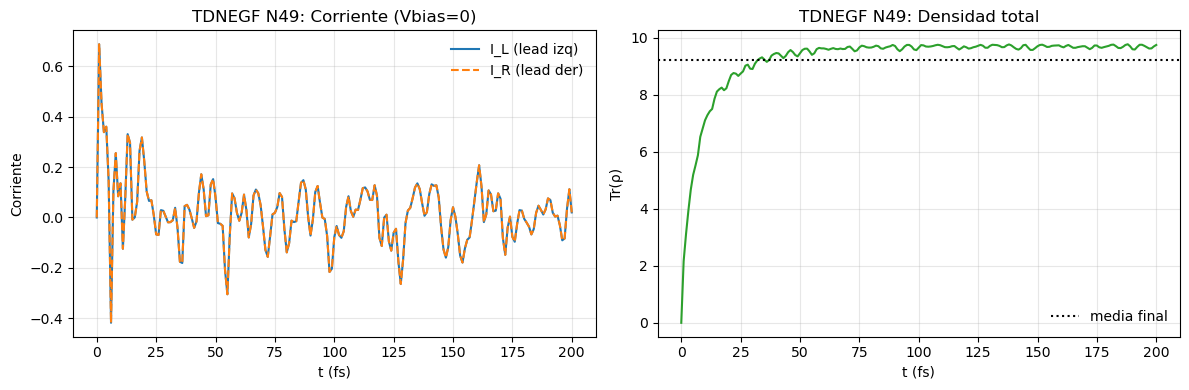

In [78]:
using PyPlot
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["figure.dpi"] = 100

fig, axs = subplots(1, 2, figsize=(12, 4))

# Corriente
axs[1].plot(sol.t, I_L, label="I_L (lead izq)", lw=1.5)
axs[1].plot(sol.t, I_R, label="I_R (lead der)", lw=1.5, ls="--")
axs[1].set_xlabel("t (fs)")
axs[1].set_ylabel("Corriente")
axs[1].set_title("TDNEGF N49: Corriente (Vbias=0)")
axs[1].legend(frameon=false)
axs[1].grid(true, alpha=0.3)

# Densidad total
axs[2].plot(sol.t, total_charge, lw=1.5, color="tab:green")
axs[2].axhline(mean(total_charge[end-200:end]), color="k", ls=":", label="media final")
axs[2].set_xlabel("t (fs)")
axs[2].set_ylabel("Tr(ρ)")
axs[2].set_title("TDNEGF N49: Densidad total")
axs[2].legend(frameon=false)
axs[2].grid(true, alpha=0.3)

tight_layout()
println("Valor de estado estacionario Tr(ρ): $(round(mean(total_charge[end-200:end]), digits=4))")

### Densidad por sitio (perfil espacial al final)

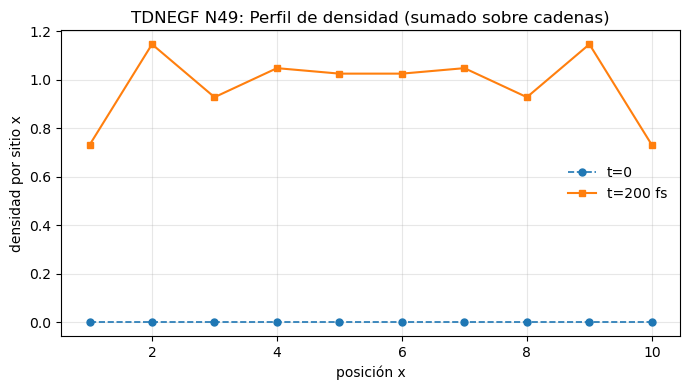

In [79]:
# obs.n_i tiene shape (N_sites, N_tmax) donde N_sites = Nx*Ny = 20
# Nota: n_i[i,t] es la densidad del sitio i = (x-1)*Ny + y en el nuevo código

n_final = obs.n_i[:, end]
n_init  = obs.n_i[:, 1]

# Agrupar por posición x (suma sobre cadenas)
n_x_final = [sum(n_final[(x-1)*Ny+1 : x*Ny]) for x in 1:Nx]
n_x_init  = [sum(n_init[ (x-1)*Ny+1 : x*Ny]) for x in 1:Nx]

fig2, ax2 = subplots(1, 1, figsize=(7, 4))
ax2.plot(1:Nx, n_x_init,  "o--", label="t=0",    lw=1.2, ms=5)
ax2.plot(1:Nx, n_x_final, "s-",  label="t=$(Int(t_end)) fs", lw=1.5, ms=5)
ax2.set_xlabel("posición x")
ax2.set_ylabel("densidad por sitio x")
ax2.set_title("TDNEGF N49: Perfil de densidad (sumado sobre cadenas)")
ax2.legend(frameon=false)
ax2.grid(true, alpha=0.3)
tight_layout()

## Sección 9: Guardar resultados

In [80]:
mkpath(joinpath(dirname(dirname(@__DIR__)), "examples", "data"))
save_path = joinpath(dirname(dirname(@__DIR__)), "examples", "data", "benchmark_legacy_n49.jld2")

# Renombrar antes de guardar (jldsave no acepta expresiones en el bloque)
t_sol  = sol.t
n_i    = obs.n_i

jldsave(save_path;
    Nx, Ny, N_orb, Nσ, Ns, Nα, Nc_lead,
    tc1, tc2, tc, tv, Δ,
    N_λ1, N_λ2, β, μ, Vbias,
    t_end, dt,
    H, ξ_L, ξ_R,
    ΣL_nλ, ΣG_nλ, χ_nλ,
    t=t_sol,
    I_L, I_R,
    n_i,
    total_charge,
)

println("✓ Resultados guardados en: $save_path")

✓ Resultados guardados en: /home/jalil/jalil_codes/Projects_2026/TDNEGF/examples/data/benchmark_legacy_n49.jld2


## Sección 10: Comparación con el código legacy (TDNEGF_exciton_B)

Para comparar con el legacy es necesario primero correr el script de referencia que genera los datos del código viejo.  
Ejecutar desde terminal:

```bash
cd /home/jalil/jalil_codes/Projects_2026/TDNEGF
julia examples/run_legacy_bench.jl
```

Esto genera `examples/data/legacy_bench_curr.txt` y `examples/data/legacy_bench_cden.txt`.

### Criterio de éxito
- Corriente: `|I_L_new - I_L_legacy| / |I_L_legacy|` < 1% en estado estacionario
- Densidad total: `|Tr(ρ)_new - Tr(ρ)_legacy|` < 0.5 en estado estacionario

Legacy: n_leg=200, I_L_leg=200, total_charge_leg=200
Nuevo:  t_new=201, I_L=201, total_charge_new=201

Estado estacionario Tr(ρ):
  Legacy (N31): 18.6002
  Nuevo  (N49): 9.7009
  Diferencia:   8.8993


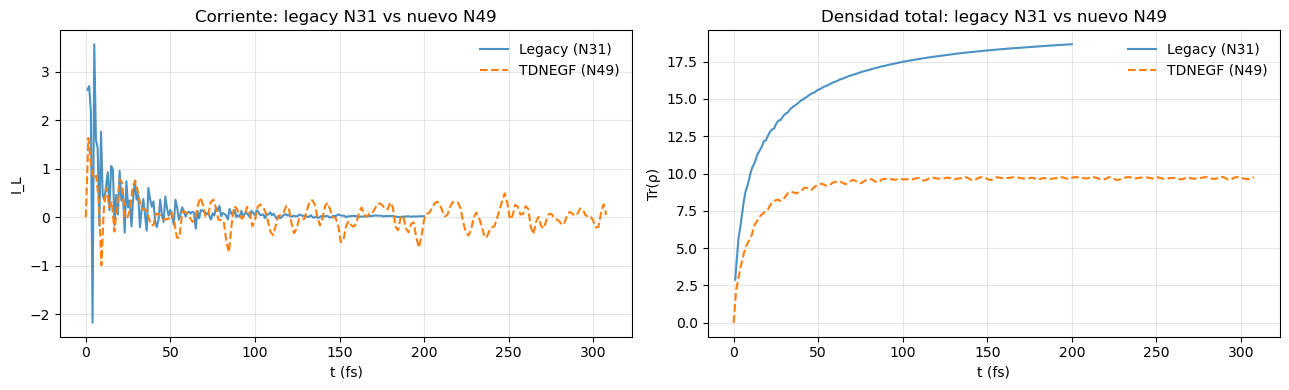

In [96]:
legacy_curr_path = joinpath(dirname(dirname(@__DIR__)), "examples", "data", "legacy_bench_curr.txt")
legacy_cden_path = joinpath(dirname(dirname(@__DIR__)), "examples", "data", "legacy_bench_cden.txt")

if isfile(legacy_curr_path) && isfile(legacy_cden_path)
    # Corriente: 400×1, filas intercaladas [I_L(t1); I_R(t1); I_L(t2); ...]
    legacy_curr_raw = vec(readdlm(legacy_curr_path, Float64))
    I_L_leg = legacy_curr_raw[1:2:end]   # impares = canal L
    I_R_leg = legacy_curr_raw[2:2:end]   # pares   = canal R
    n_leg   = length(I_L_leg)            # 200 pasos

    # Densidad: 8000×1, [site1(t1), ..., site40(t1), site1(t2), ...]
    legacy_cden_raw = vec(readdlm(legacy_cden_path, Float64))
    N_sites_leg = 40
    legacy_cden = reshape(legacy_cden_raw, N_sites_leg, n_leg)  # 40 × 200
    total_charge_leg = vec(sum(legacy_cden, dims=1))             # 200 valores

    t_leg = collect(range(1.0, step=1.0, length=n_leg))

    println("Legacy: n_leg=$n_leg, I_L_leg=$(length(I_L_leg)), total_charge_leg=$(length(total_charge_leg))")

    # Eje temporal y observables del código nuevo (consistentes con I_L)
    t_new            = obs.t
    total_charge_new = vec(sum(obs.n_i, dims=1))

    println("Nuevo:  t_new=$(length(t_new)), I_L=$(length(I_L)), total_charge_new=$(length(total_charge_new))")

    fig3, axs3 = subplots(1, 2, figsize=(13, 4))

    axs3[1].plot(t_leg, I_L_leg, label="Legacy (N31)",  lw=1.5, alpha=0.8)
    axs3[1].plot(t_new/0.65, I_L/0.65^2,     label="TDNEGF (N49)",  lw=1.5, ls="--")
    axs3[1].set_xlabel("t (fs)")
    axs3[1].set_ylabel("I_L")
    axs3[1].set_title("Corriente: legacy N31 vs nuevo N49")
    axs3[1].legend(frameon=false)
    axs3[1].grid(true, alpha=0.3)

    axs3[2].plot(t_leg, total_charge_leg,  label="Legacy (N31)", lw=1.5, alpha=0.8)
    axs3[2].plot(t_new/0.65, total_charge_new,  label="TDNEGF (N49)", lw=1.5, ls="--")
    axs3[2].set_xlabel("t (fs)")
    axs3[2].set_ylabel("Tr(ρ)")
    axs3[2].set_title("Densidad total: legacy N31 vs nuevo N49")
    axs3[2].legend(frameon=false)
    axs3[2].grid(true, alpha=0.3)

    tight_layout()

    # Comparación cuantitativa (últimos 20 puntos)
    n_ss = min(20, length(total_charge_new)-1, length(total_charge_leg)-1)
    ss_new = mean(total_charge_new[end-n_ss:end])
    ss_leg = mean(total_charge_leg[end-n_ss:end])
    println("
Estado estacionario Tr(ρ):")
    println("  Legacy (N31): $(round(ss_leg, digits=4))")
    println("  Nuevo  (N49): $(round(ss_new, digits=4))")
    println("  Diferencia:   $(round(abs(ss_new - ss_leg), digits=4))")
else
    println("Datos legacy no encontrados. Ejecutar primero:")
    println("  julia --project=. examples/run_legacy_bench.jl")
end

In [97]:
#total_charge_leg[1:200]
#1/0.64^2

In [98]:
#collect(t_leg)